In [1]:
import os
import re
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats

plt.style.use('bmh')

PYTHON_PATH = '/home/andreas/mambaforge/envs/symdel/bin/python'
WORKER_SCRIPTS = {
    'symscan': 'tmp/symscan_memory_worker.py',
    'symdel': 'tmp/symdel_memory_worker.py',
}
SEQ_FILE = 'tmp/emerson_sequences.txt'
MAX_DISTANCE = 1
DISTANCE_TYPE = 'levenshtein'
N_REPS = 1

In [2]:
!mkdir -p tmp

In [3]:
if not os.path.exists(SEQ_FILE):
    df = pd.concat([
        pd.read_csv(f'../data/emerson_rep{i}.zip', sep=',', compression='zip')
        for i in range(1, 15)
        ])
    seqs = df['cdr3'].drop_duplicates().sample(frac=1, random_state=0).reset_index(drop=True)
    len_seqs = len(seqs)
    with open(SEQ_FILE, 'w') as f:
        f.write('\n'.join(seqs) + '\n')
else:
    with open(SEQ_FILE) as f:
        len_seqs = len(f.readlines())


In [4]:
len_seqs

57472488

In [5]:
%%writefile tmp/symscan_memory_worker.py
# Standalone worker run as a fresh subprocess for each measurement, so that the peak RSS
# reported by `/usr/bin/time -v` reflects a single symscan.get_neighbors_within call in
# isolation rather than a cumulative/high-water mark across many calls in one process.
import sys

import symscan


def main():
    seq_file, n_sequence, max_distance = sys.argv[1:4]
    n_sequence = int(n_sequence)
    max_distance = int(max_distance)

    with open(seq_file) as f:
        seqs = [next(f).strip() for _ in range(n_sequence)]

    symscan.get_neighbors_within(seqs, max_distance=max_distance)


if __name__ == '__main__':
    main()

Overwriting tmp/symscan_memory_worker.py


In [6]:
%%writefile tmp/symdel_memory_worker.py
# Standalone worker run as a fresh subprocess for each measurement, so that the peak RSS
# reported by `/usr/bin/time -v` reflects a single pyrepseq.symdel call in
# isolation rather than a cumulative/high-water mark across many calls in one process.
import sys

import pyrepseq


def main():
    seq_file, n_sequence, max_distance = sys.argv[1:4]
    n_sequence = int(n_sequence)
    max_distance = int(max_distance)

    with open(seq_file) as f:
        seqs = [next(f).strip() for _ in range(n_sequence)]


    pyrepseq.symdel(seqs, max_edits=max_distance)


if __name__ == '__main__':
    main()

Overwriting tmp/symdel_memory_worker.py


In [7]:
def measure_peak_memory_gb(algorithm, n_sequence, max_distance=MAX_DISTANCE):
    cmd = ['/usr/bin/time', '-v', PYTHON_PATH, WORKER_SCRIPTS[algorithm],
           SEQ_FILE, str(n_sequence), str(max_distance)]
    result = subprocess.run(cmd, capture_output=True, text=True)
    match = re.search(r'Maximum resident set size \(kbytes\): (\d+)', result.stderr)
    if match is None:
        raise RuntimeError(result.stderr)
    return int(match.group(1)) / 1024**2

sizes = np.unique(np.geomspace(1e5, len_seqs, num=12, dtype=int))
sizes

array([  100000,   178180,   317482,   565691,  1007952,  1795973,
        3200073,  5701905, 10159679, 18102560, 32255219, 57472488])

In [8]:
rows = []
for algorithm in WORKER_SCRIPTS:
    for n_sequence in sizes:
        for rep in range(N_REPS):
            memory_gb = measure_peak_memory_gb(algorithm, n_sequence)
            rows.append({'algorithm': algorithm, 'n_sequence': n_sequence,
                          'distance': MAX_DISTANCE, 'measure': 'memory_gb',
                          'memory_gb': memory_gb})
            print(algorithm, n_sequence, rep, memory_gb)
        if memory_gb > 32:
            print(f"Memory usage exceeded 32 GB for {algorithm} with {n_sequence} sequences. Stopping further measurements for this algorithm.")
            break

symscan 100000 0 0.043701171875
symscan 178180 0 0.071533203125
symscan 317482 0 0.11865234375
symscan 565691 0 0.20556640625
symscan 1007952 0 0.360107421875
symscan 1795973 0 0.636962890625
symscan 3200073 0 1.127197265625
symscan 5701905 0 2.004852294921875
symscan 10159679 0 3.597118377685547
symscan 18102560 0 6.452861785888672
symscan 32255219 0 11.576148986816406
symscan 57472488 0 26.81311798095703
symdel 100000 0 0.7119102478027344
symdel 178180 0 0.845367431640625
symdel 317482 0 1.1778945922851562
symdel 565691 0 1.7841873168945312
symdel 1007952 0 2.89959716796875
symdel 1795973 0 4.933238983154297
symdel 3200073 0 7.729240417480469
symdel 5701905 0 14.069839477539062
symdel 10159679 0 25.30394744873047
symdel 18102560 0 49.62667465209961


KeyboardInterrupt: 

scaling exponent: 0.995 +/- 0.014
scaling exponent: 0.832 +/- 0.037


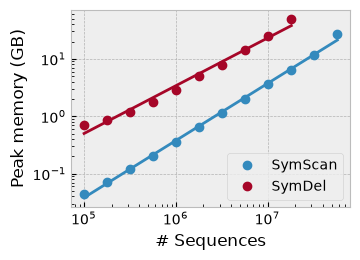

In [ ]:
mem_df = pd.DataFrame(rows)
mem_df.to_csv('../data/symscan_memory_benchmark.csv')

fig, ax = plt.subplots(figsize=(3.4, 2.4))

for algorithm in WORKER_SCRIPTS:
    mean = mem_df[mem_df['algorithm'] == algorithm].groupby('n_sequence')['memory_gb'].mean()
    x, y = mean.index.values, mean.values
    slope, intercept, r, p, se = scipy.stats.linregress(np.log(x), np.log(y))
    print(f'scaling exponent: {slope:.3} +/- {se:.2}')

    l, = ax.plot(x, y, 'o', label='SymScan' if algorithm == 'symscan' else 'SymDel')
    ax.plot(x, np.exp(slope * np.log(x) + intercept), '-', color=l.get_color())
ax.legend(loc='lower right')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('# Sequences')
ax.set_ylabel('Peak memory (GB)')
fig.tight_layout(pad=0.0)
fig.savefig('figs/symscan_memory_benchmark.svg')